In [4]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [5]:
problems = ["nguyen_9_12", "nguyen_9", "nguyen_10", "nguyen_12"]
seeds = range(5)
algorithms = ["ga", "gomea"]
solvers = ["cgp"]

dfs = []
column_names = ["evaluation", "fitness", "time", "test_accuracy"]
for solver in solvers:
    for algorithm in algorithms:
        for problem in problems:
            for seed in seeds:
                # for dense in [False, True]:
                for dense in [True]:
                    processed_problem = f"{problem}_dense" if dense else problem
                    if algorithm == "gomea":
                        for fos in ["U", "RT", "LT", "N1", "N2"]:
                            try:
                                tmp_df = pd.read_csv(f"../results/{algorithm}_{solver}_{processed_problem}_{fos}_{seed}_fi.csv",
                                                     header=None, names=column_names, skiprows=1)
                                tmp_df["seed"] = seed
                                tmp_df["algorithm"] = f"{algorithm}_{fos}"
                                tmp_df["problem"] = problem
                                tmp_df["solver"] = solver
                                tmp_df["n_points"] = 200 if dense else 20
                                dfs.append(tmp_df)
                            except Exception as e:
                                print(e)
                    else:
                        tmp_df = pd.read_csv(f"../results/{algorithm}_{solver}_{processed_problem}_{seed}.csv", header=None,
                                             names=column_names, skiprows=1)
                        tmp_df["seed"] = seed
                        tmp_df["algorithm"] = algorithm
                        tmp_df["problem"] = problem
                        tmp_df["solver"] = solver
                        tmp_df["n_points"] = 200 if dense else 20
                        dfs.append(tmp_df)
regression_df = pd.concat(dfs, ignore_index=True)
regression_df.head()

[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_9_12_dense_LT_0_fi.csv'
[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_9_12_dense_LT_1_fi.csv'
[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_9_12_dense_LT_2_fi.csv'
[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_9_12_dense_LT_3_fi.csv'
[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_9_12_dense_LT_4_fi.csv'
[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_10_dense_LT_0_fi.csv'
[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_10_dense_LT_1_fi.csv'
[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_10_dense_LT_2_fi.csv'
[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_10_dense_LT_3_fi.csv'
[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_10_dense_LT_4_fi.csv'
[Errno 2] No such file or directory: '../results/gomea_cgp_nguyen_12_dense_LT_0_fi.csv'
[Errno 2] No such file

,evaluation,fitness,time,test_accuracy,seed,algorithm,problem,solver,n_points
0,0,-1.849388,-1.408627,0.98,0,ga,nguyen_9_12,cgp,200
1,100,-1.632435,-1.571166,0.46,0,ga,nguyen_9_12,cgp,200
2,200,-1.632435,-1.571166,0.42,0,ga,nguyen_9_12,cgp,200
3,300,-1.632435,-1.571166,0.45,0,ga,nguyen_9_12,cgp,200
4,400,-1.632435,-1.571166,0.44,0,ga,nguyen_9_12,cgp,200


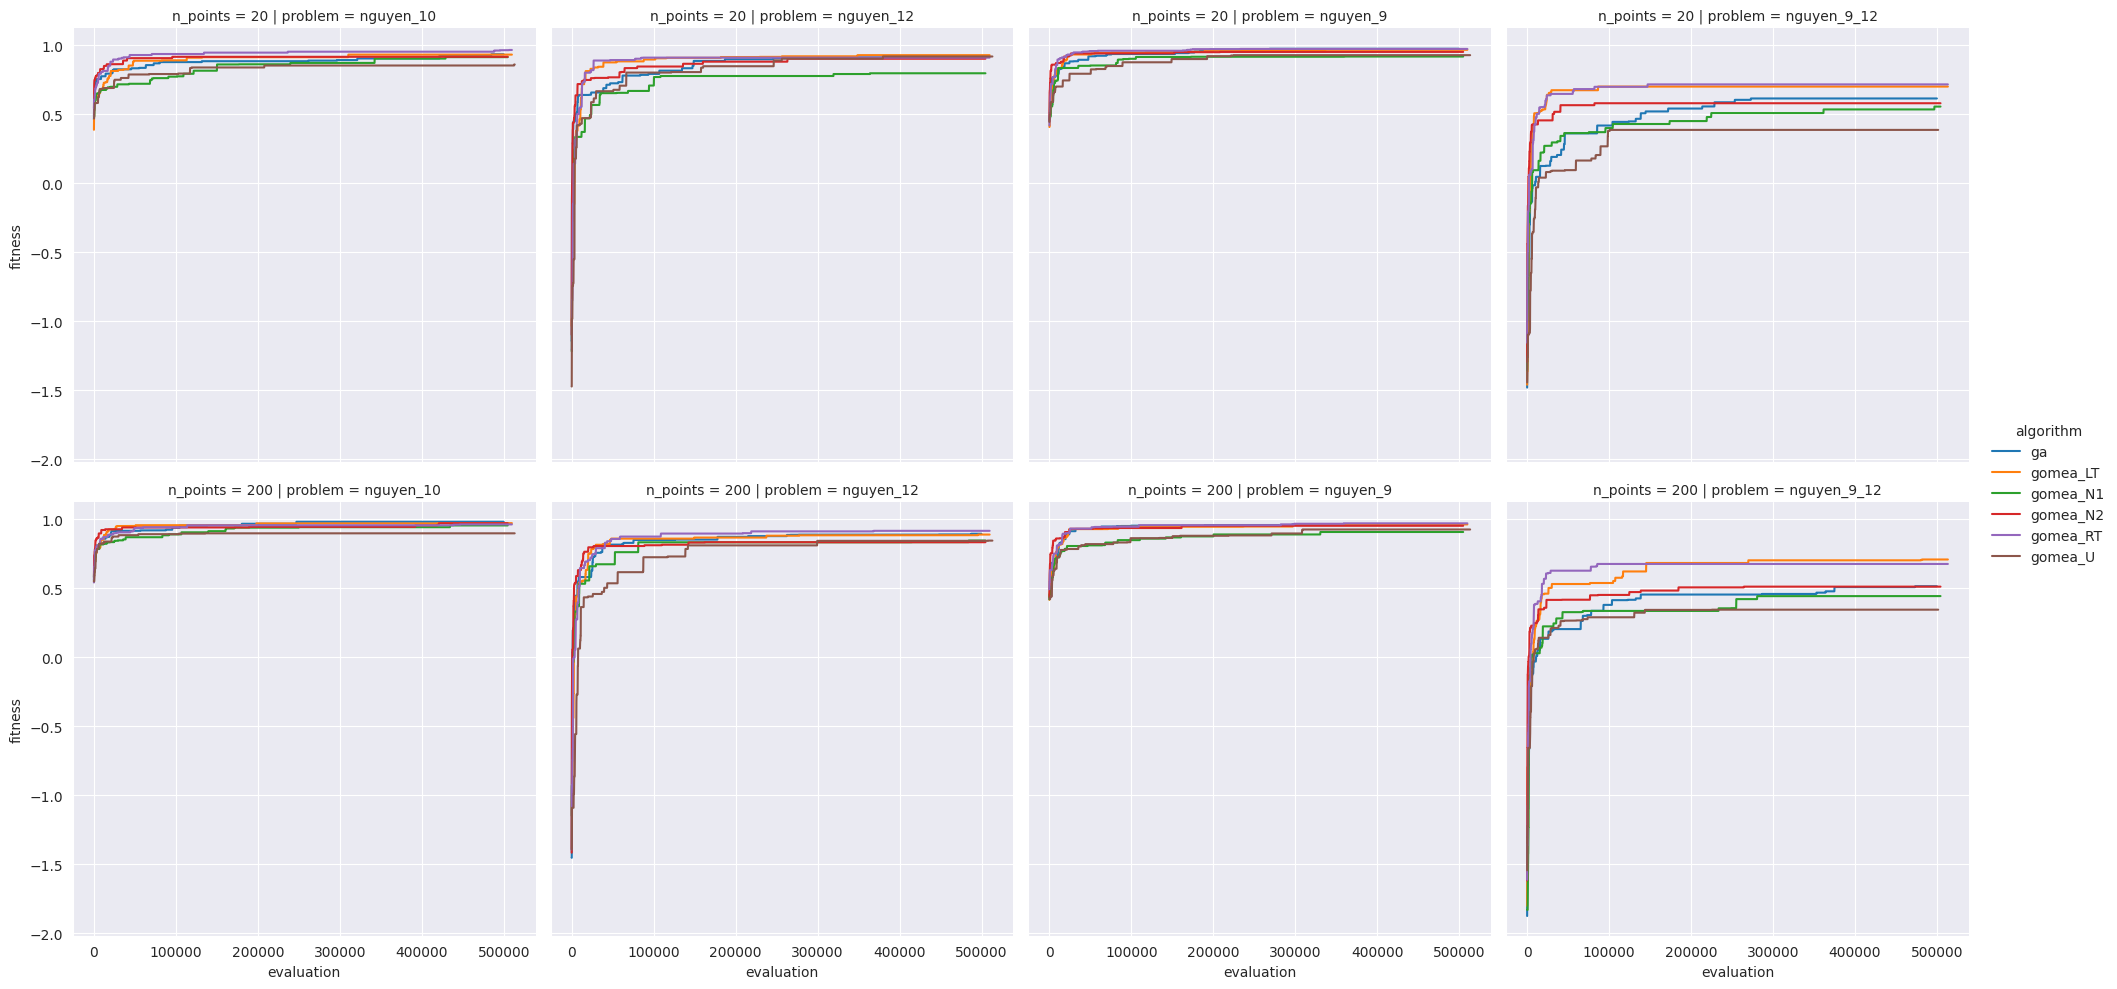

In [21]:
agg_df = (
    regression_df
    .groupby(["evaluation", "problem", "algorithm", "solver", "n_points"])
    .mean()
    .reset_index()
)
sns.relplot(
    agg_df,
    x="evaluation",
    y="fitness",
    col="problem",
    row="n_points",
    hue="algorithm",
    kind="line",
)
plt.show()

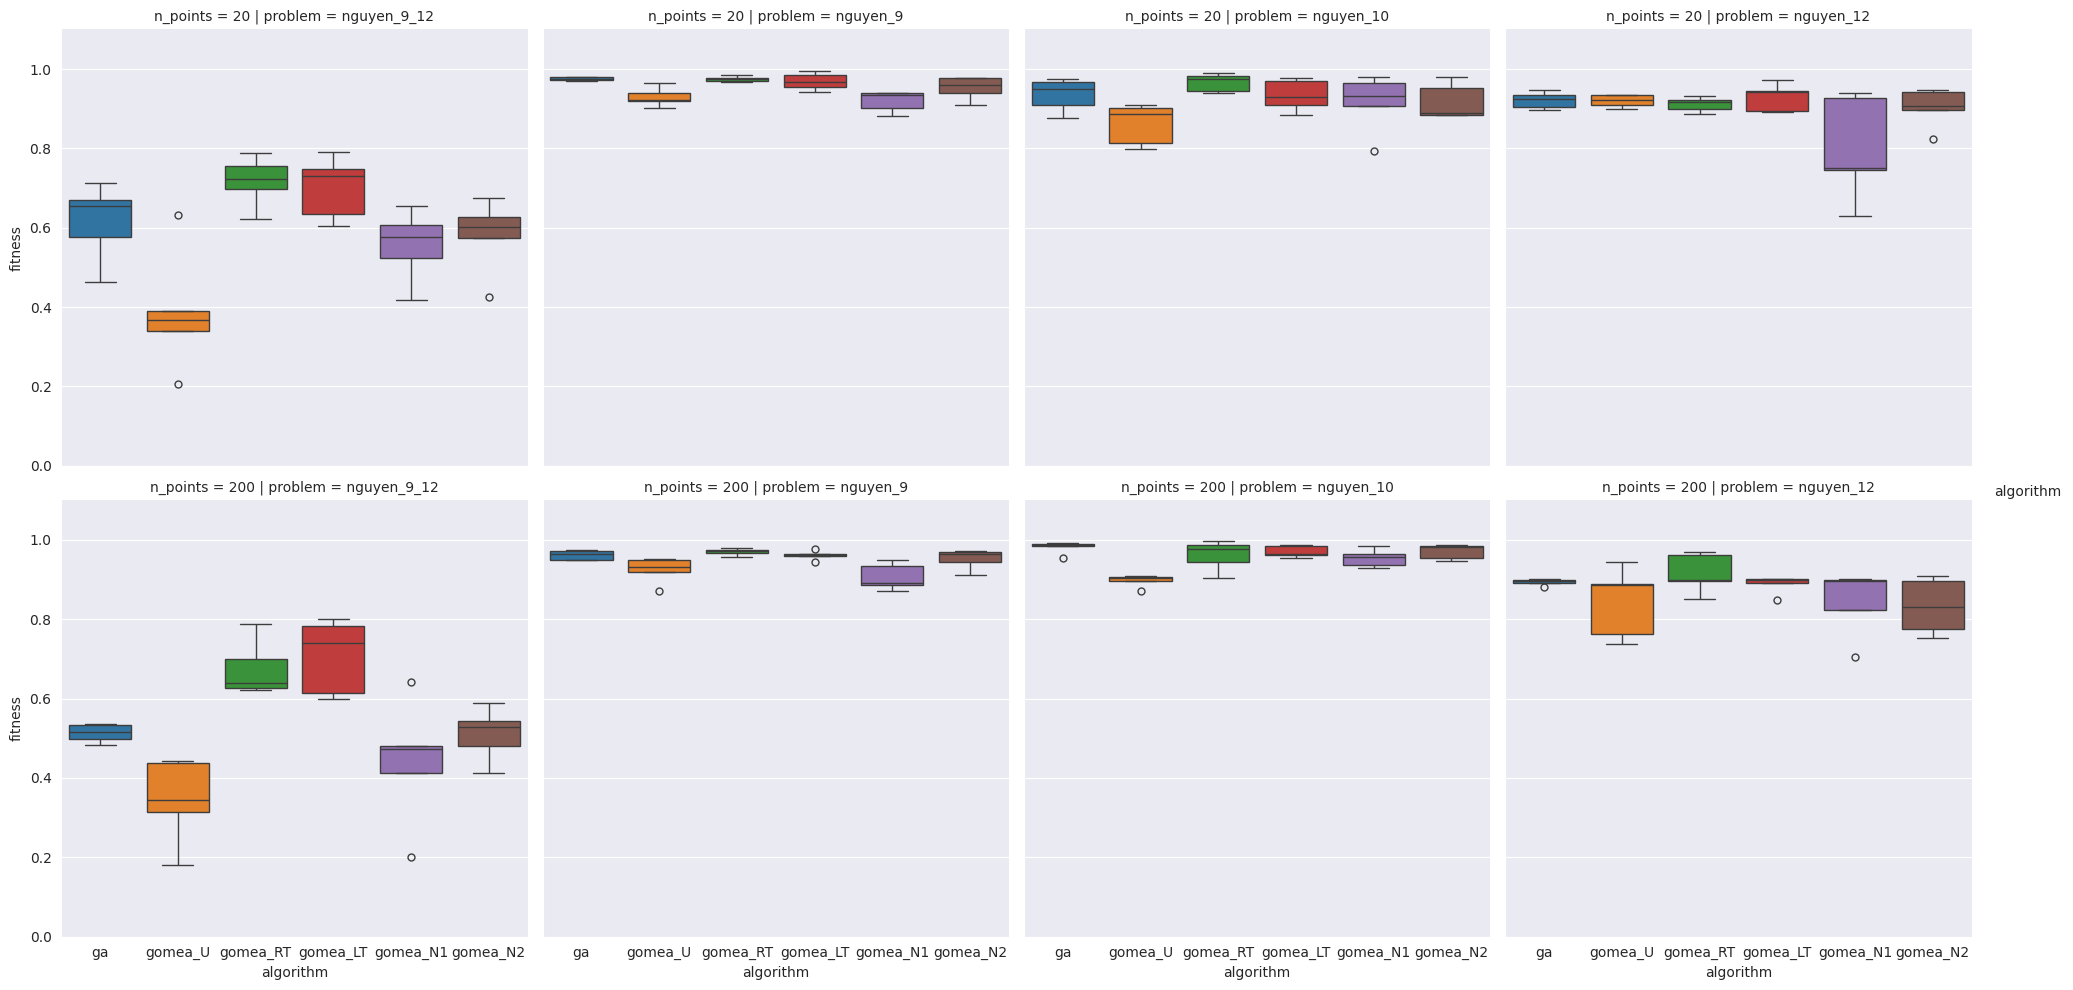

In [22]:
regression_df["max_eval"] = regression_df.groupby(["algorithm", "problem", "seed"])["evaluation"].transform("max")
final_regression_df = regression_df[regression_df["evaluation"] == regression_df["max_eval"]].drop(columns="max_eval")
sns.catplot(
    data=final_regression_df, x='algorithm', y='fitness', hue="algorithm",
    col='problem', kind='box', row="n_points",
)
plt.ylim(0, 1.1)
plt.show()

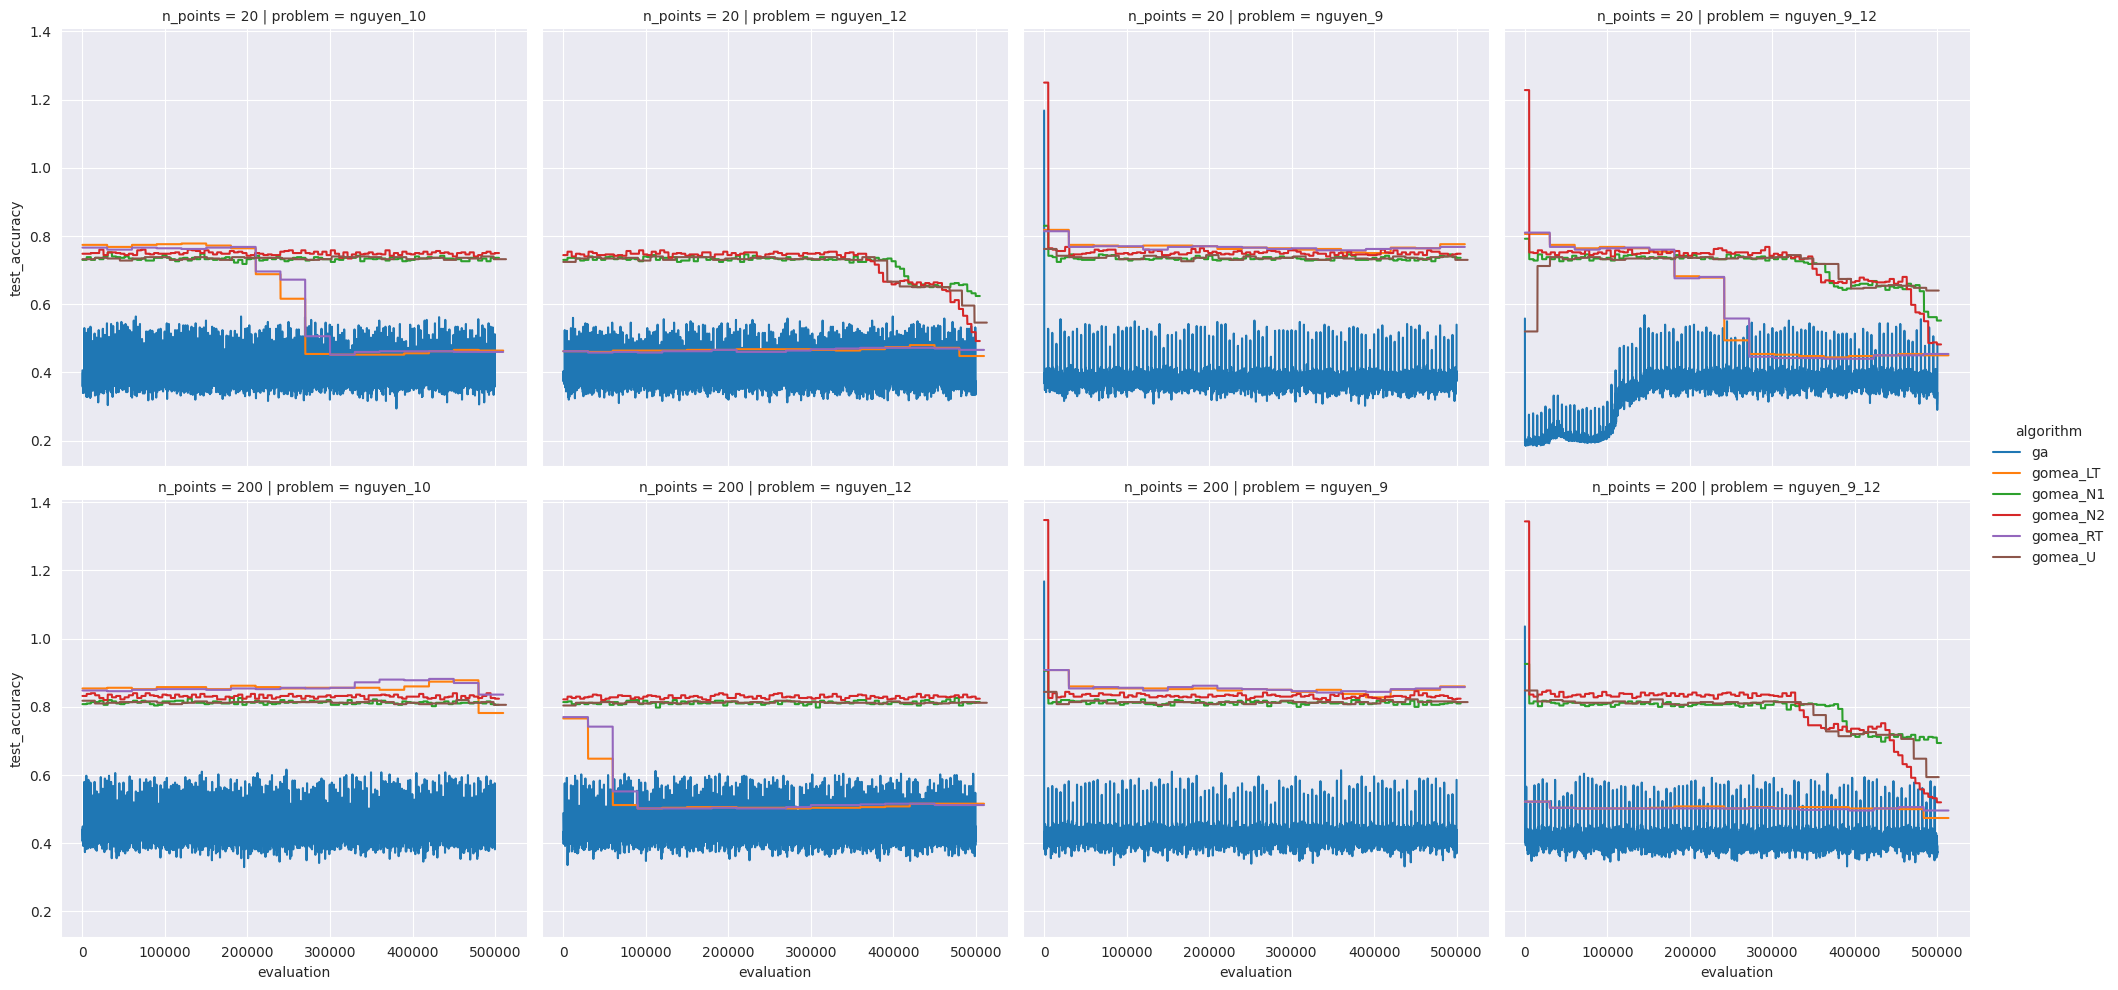

In [23]:
sns.relplot(
    agg_df,
    x="evaluation",
    y="test_accuracy",
    hue="algorithm",
    col="problem",
    kind="line",
    row="n_points",
)
plt.show()

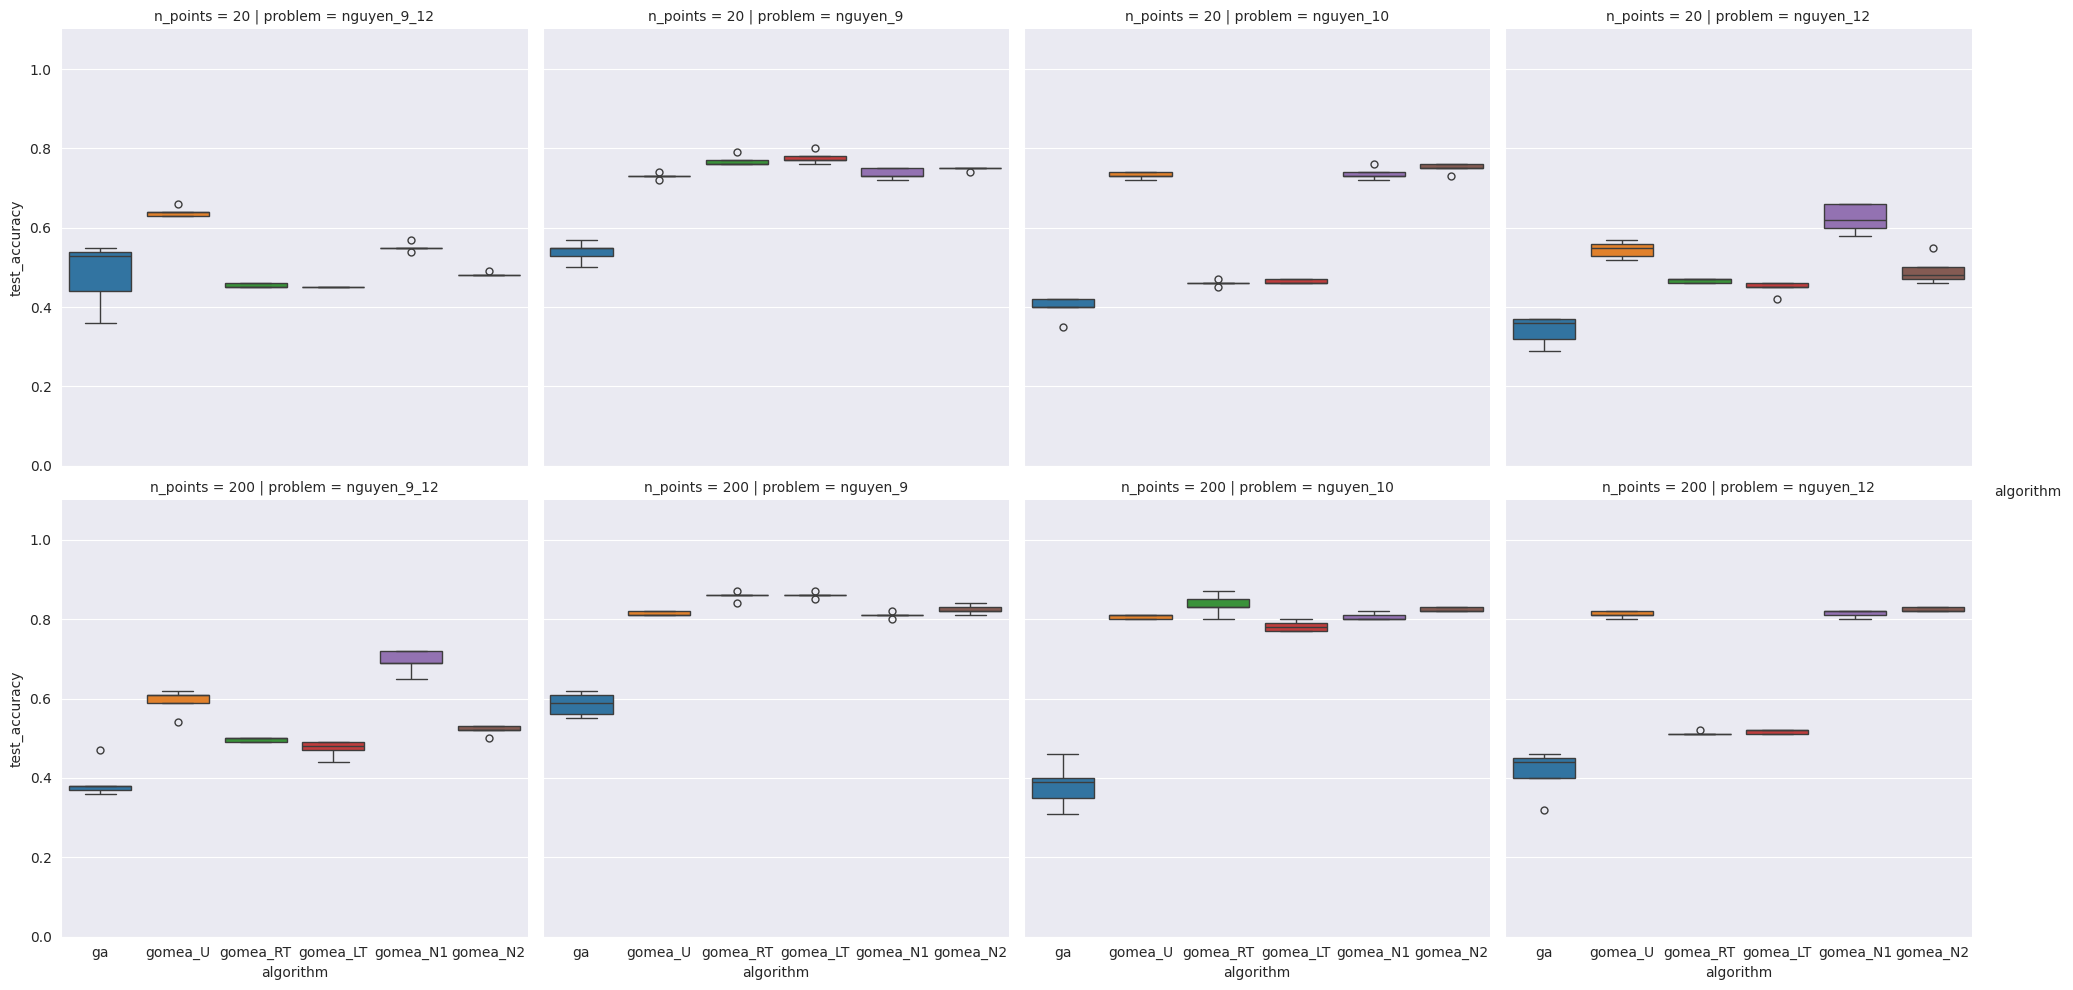

In [24]:
sns.catplot(
    data=final_regression_df, x='algorithm', y='test_accuracy', hue="algorithm",
    col='problem', kind='box', row="n_points",
)
plt.ylim(0, 1.1)
plt.show()